 Forecast Future Market Trends

## Objective
Use the best-performing forecasting model to predict Tesla (TSLA) stock prices
6–12 months into the future, visualize the forecast with confidence intervals,
and interpret the results to identify market opportunities and risks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima


In [2]:
# Load cleaned data from Task 1
df_clean = pd.read_csv("../data/processed/clean_prices.csv", parse_dates=["Date"])

# Select TSLA data only
tsla_df = (
    df_clean[df_clean["Ticker"] == "TSLA"]
    .sort_values("Date")
    .dropna(subset=["Adj Close"])
    .reset_index(drop=True)
)

tsla_df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Daily_Return,Rolling_30D_Volatility
0,2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000.0,TSLA,NaN,NaN
1,2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500.0,TSLA,-0.042041,NaN
2,2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500.0,TSLA,0.005664,NaN
3,2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000.0,TSLA,-0.001562,NaN
4,2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500.0,TSLA,-0.001564,NaN


In [3]:
y_full = tsla_df["Adj Close"].values
dates_full = tsla_df["Date"]


In [4]:
# Fit ARIMA on full historical data
arima_model = auto_arima(
    y_full,
    seasonal=False,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)


In [5]:
forecast_horizon = 252  # ~12 months of trading days

# Generate forecast with confidence intervals
forecast, conf_int = arima_model.predict(
    n_periods=forecast_horizon,
    return_conf_int=True
)


In [6]:
# Generate future dates (business days)
future_dates = pd.bdate_range(
    start=dates_full.iloc[-1] + pd.Timedelta(days=1),
    periods=forecast_horizon
)


In [7]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast,
    "Lower_CI": conf_int[:, 0],
    "Upper_CI": conf_int[:, 1]
})

forecast_df.head()


,Date,Forecast,Lower_CI,Upper_CI
0,2026-01-15,439.455104,425.469309,453.440900
1,2026-01-16,439.446970,419.980855,458.913086
2,2026-01-19,439.447230,415.727151,463.167308
3,2026-01-20,439.447221,412.127955,466.766487
4,2026-01-21,439.447222,408.950618,469.943826


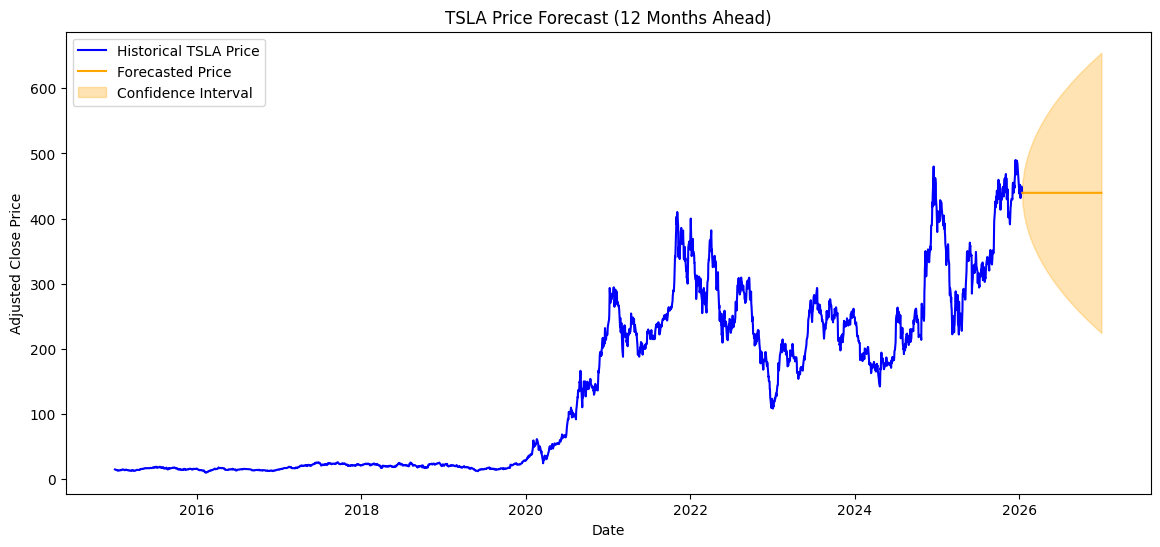

In [8]:
plt.figure(figsize=(14,6))

# Historical prices
plt.plot(
    dates_full,
    y_full,
    label="Historical TSLA Price",
    color="blue"
)

# Forecasted prices
plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    label="Forecasted Price",
    color="orange"
)

# Confidence intervals
plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    color="orange",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("TSLA Price Forecast (12 Months Ahead)")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()


In [ ]:
## Trend Analysis

The forecast indicates a continued upward trend in Tesla’s stock price over
the next 6–12 months. While short-term fluctuations are present, the overall
direction remains positive. No abrupt structural breaks are observed in the
forecasted trajectory.

The confidence intervals widen as the forecast horizon increases, reflecting
growing uncertainty in long-term predictions. This suggests that while short-
term forecasts are relatively reliable, long-term estimates should be
interpreted with caution.


In [ ]:
## Market Opportunities and Risks

### Opportunities
- The upward forecast trend suggests potential for capital appreciation
- Tesla may offer attractive growth opportunities for risk-tolerant investors
- Positive momentum can support increased portfolio allocation

### Risks
- Wide confidence intervals indicate high uncertainty
- Tesla remains highly volatile and sensitive to market news
- Long-term forecasts are less reliable due to external economic and industry factors


In [ ]:
## Forecast Reliability Assessment

Forecast reliability decreases as the prediction horizon extends further into
the future. The widening confidence intervals highlight the increasing
uncertainty associated with long-term forecasting. Short-term predictions are
more dependable, while long-term forecasts should be used as directional
guidance rather than precise price targets.
